In [ ]:
import pandas as pd
import os
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Projekt_Mobilisierung/Data/all_party_accs.csv')

In [ ]:
!pip install -q openai backoff gpt-cost-estimator

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 262.9/262.9 kB 2.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.6/75.6 kB 2.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 11.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.9/77.9 kB 7.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.3/58.3 kB 5.1 MB/s eta 0:00:00


In [ ]:
import openai
from openai import OpenAI
from google.colab import userdata
import backoff
from gpt_cost_estimator import CostEstimator


#@title Setup for the OpenAI API

#@markdown We're using the new Colab Feature to store keys safely within the Colab Environment.
#@markdown Click on the key on the left to add your API key and enable it for this notebook.
#@markdown Enter the name of your API-Key below.
api_key_name = "dere2" # @param {type: "string"}
api_key = userdata.get(api_key_name)

# Initialize OpenAI using the key
client = OpenAI(
    api_key=api_key
)



@CostEstimator()
def query_openai(model, temperature, messages, mock=True, completion_tokens=10):
    return client.chat.completions.create(
                      model=model,
                      temperature=temperature,
                      messages=messages,
                      max_tokens=600)

# We define the run_request method to wrap it with the @backoff decorator
@backoff.on_exception(backoff.expo, (openai.RateLimitError, openai.APIError))
def run_request(system_prompt, user_prompt, model, mock):
  messages = [
    {"role": "system", "content": system_prompt},
    {"role": "user", "content": user_prompt}
  ]

  return query_openai(
          model=model,
          temperature=0.0,
          messages=messages,
          mock=mock
        )

In [ ]:
system_prompt = """
You are an advanced classifying AI. Your task is to classify a body. Categories can be either ‘Mobilization’, 'Interaction' or ‘Fundraising’.
'mobilization' means the text tries to get people to vote a certain party or candidate. This can happen through positive inforamtion about the party, the candidate or the political content.
`Interaktion' means the text tries to engage in discussion or communication with other users online.
'Fundraising' means the text tries to raise money for a political campaign.
"""

In [ ]:
prompt = """
Please classify the following text input into either ‘Mobilization’, 'Interaction' or ‘Fundraising’. Your answer MUST be one of [‘Mobilization’, 'Interaction' or ‘Fundraising’], and it should be presented in lowercase.
Body: [BODY]
"""

In [ ]:
from tqdm.auto import tqdm
#@title Running the request.
#@markdown The following code snippet uses my [gpt-cost-estimator](https://pypi.org/project/gpt-cost-estimator/) package to simulate API requests and calculate a cost estimate. Please run the estimation whne possible to asses the price-tag before sending requests to OpenAI!

#@markdown Make sure 'run_request' and 'system_prompt' are defined before this block by running the two blocks above!

#@markdown Do you want to mock the OpenAI request (dry run) to calculate the estimated price?
MOCK = False # @param {type: "boolean"}
#@markdown Do you want to reset the cost estimation when running the query?
RESET_COST = True # @param {type: "boolean"}
#@markdown What's the column name to save the results of the data extraction task to?
COLUMN = 'Kategorie' # @param {type: "string"}
#@markdown Do you want to run the request on a smaller sample of the whole data? (Useful for testing). Enter 0 to run on the whole dataset.
SAMPLE_SIZE = 500 # @param {type: "number", min: 0}

#@markdown Which model do you want to use?
MODEL = "gpt-4-0613" # @param ["gpt-3.5-turbo-0613", "gpt-4-1106-preview", "gpt-4-0613"] {allow-input: true}


# Initializing the empty column
if COLUMN not in df.columns:
  df[COLUMN] = None

# Reset Estimates
CostEstimator.reset()
print("Reset Cost Estimaton")

filtered_df = df.copy()

# Skip previously annotated rows
filtered_df = filtered_df[pd.isna(filtered_df[COLUMN])]

if SAMPLE_SIZE > 0:
  filtered_df = filtered_df.sample(SAMPLE_SIZE)

for index, row in tqdm(filtered_df.iterrows(), total=len(filtered_df)):
    try:
        p = prompt.replace('[BODY]', row['body'])
        response = run_request(system_prompt, p, MODEL, MOCK)

        if not MOCK:
          # Extract the response content
          # Adjust the following line according to the structure of the response
          r = response.choices[0].message.content

          # Update the 'new_df' DataFrame
          df.at[index, COLUMN] = r

    except Exception as e:
        print(f"An error occurred: {e}")
        # Optionally, handle the error (e.g., by logging or by setting a default value)

print()

In [ ]:
df['Kategorie'] = df['Kategorie'].replace("mobilization", 'Mobilisierung')
df['Kategorie'] = df['Kategorie'].replace("'mobilization'", 'Mobilisierung')
df['Kategorie'] = df['Kategorie'].replace("'interaction'", 'Interaktion')
df['Kategorie'] = df['Kategorie'].replace("interaction", 'Interaktion')
df['Kategorie'] = df['Kategorie'].replace("interaktion", 'Interaktion')
df['Kategorie'] = df['Kategorie'].replace("'fundraising'", 'Fundraising')
df['Kategorie'] = df['Kategorie'].replace('The provided text "#NAME?" is not sufficient to classify into any of the categories: \'mobilization\', \'interaction\', or \'fundraising\'. Please provide a more detailed text.', 'Mobilisierung')
df['Kategorie'] = df['Kategorie'].replace("#NAME?", '☀️#Bayern ist #PV-Vorbild für ganz Deutschland 🌞😎 ++ Aktuelle Ausschreibungsrunde: Knapp die Hälfte aller Zuschläge für neue Freiflächen-#Photovoltaikanlagen entfallen auf Bayern. ++ Danke @hubertaiwanger #Aiwanger💪 🧡')

In [ ]:
df = df[df['Kategorie'].isin(['Mobilisierung', 'Interaktion', 'Fundraising'])]

In [ ]:
df

,Unnamed: 0.1,Unnamed: 0,id,thread_id,parent_id,body,author,author_fullname,author_avatar_url,timestamp,...,num_likes,num_comments,num_media,location_name,location_latlong,location_city,unix_timestamp,image_file,ocr_text,Kategorie
2,2,2,CyDI9sItCkE,CyDI9sItCkE,CyDI9sItCkE,+++ Ampel finanziert Antifa-„Seenotretter“ mit...,afdlandtagbayern,AfD im Landtag von Bayern,https://scontent-fra5-1.cdninstagram.com/v/t51...,06.10.2023 07:31,...,166.0,13.0,1.0,NaN,NaN,NaN,1.696577e+09,media/images/CyDI9sItCkE.jpg,Millionen füir Seenotretter : CDU und CSU sti...,Mobilisierung
27,27,27,CxnIs9woIHG,CxnIs9woIHG,CxnIs9woIHG,+++ Kurz vor der Landtagswahl übernimmt Söder ...,afdlandtagbayern,AfD im Landtag von Bayern,https://scontent-fra5-1.cdninstagram.com/v/t51...,25.09.2023 10:30,...,202.0,5.0,1.0,NaN,NaN,NaN,1.695638e+09,media/images/CxnIs9woIHG.jpg,Wir brauchen eine echte Migrationswende und ke...,Mobilisierung
29,29,29,CxhvDGioPWP,CxhvDGioPWP,CxhvDGioPWP,+++ Bayerns Ankerzentren sind völlig überfüllt...,afdlandtagbayern,AfD im Landtag von Bayern,https://scontent-fra5-1.cdninstagram.com/v/t51...,23.09.2023 08:09,...,109.0,11.0,1.0,NaN,NaN,NaN,1.695457e+09,media/images/CxhvDGioPWP.jpg,ANKERZENTREN SIND UBERFULLT! FAESER WILLTROIZD...,Mobilisierung
36,36,36,CxNJoIrIgCH,CxNJoIrIgCH,CxNJoIrIgCH,+++ Die Brandmauer ist gefallen – AfD setzt in...,afdlandtagbayern,AfD im Landtag von Bayern,https://scontent-fra5-1.cdninstagram.com/v/t51...,15.09.2023 08:18,...,339.0,7.0,1.0,NaN,NaN,NaN,1.694766e+09,media/images/CxNJoIrIgCH.jpg,THÜRINGEN: AfD SETZT SIEUERSENKUNGEN DURCH! Ta...,Mobilisierung
38,38,38,CxIL_LzoUth,CxIL_LzoUth,CxIL_LzoUth,+++ Trotz 45 Jahren Vollzeit-Arbeit – Millione...,afdlandtagbayern,AfD im Landtag von Bayern,https://scontent-fra5-1.cdninstagram.com/v/t51...,13.09.2023 10:02,...,79.0,3.0,1.0,NaN,NaN,NaN,1.694599e+09,media/images/CxIL_LzoUth.jpg,MILLIONEN BÜRGERN DROHT ALTERSARMUT! Landtag B...,Mobilisierung
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,2995,2995,Cr0Q45VKYjy,Cr0Q45VKYjy,Cr0Q45VKYjy,Der Bayerische Verfassungsgerichtshof (BayVerf...,dielinke.bayern,DIE LINKE. Bayern,https://scontent-fra5-1.cdninstagram.com/v/t51...,04.05.2023 09:43,...,95.0,1.0,2.0,NaN,NaN,NaN,1.683193e+09,media/images/Cr0Q45VKYjy.jpg,Freistaat statt Polizeistaat #noPAG DIELiNKE.,Interaktion
2997,2997,2997,CrvNUCaKbaL,CrvNUCaKbaL,CrvNUCaKbaL,Am 2. Mai 1933 stürmten die Nazis die Gewerksc...,dielinke.bayern,DIE LINKE. Bayern,https://scontent-fra5-1.cdninstagram.com/v/t51...,02.05.2023 10:36,...,198.0,25.0,2.0,NaN,NaN,NaN,1.683024e+09,media/images/CrvNUCaKbaL.jpg,2. Mai 1933 Nie wieder Faschismus DIE LiNKE. F...,Mobilisierung
3000,3000,3000,CrlKno-IhSq,CrlKno-IhSq,CrlKno-IhSq,Wir rufen auch in diesem Jahr wieder unsere Mi...,dielinke.bayern,DIE LINKE. Bayern,https://scontent-fra5-1.cdninstagram.com/v/t51...,28.04.2023 13:00,...,64.0,0.0,1.0,NaN,NaN,NaN,1.682687e+09,media/images/CrlKno-IhSq.jpg,Heraus zum 1. Mai UNGEBROGHEI DIELiNKE. SOLIDA...,Mobilisierung
3002,3002,3002,CrdUSWmNF6s,CrdUSWmNF6s,CrdUSWmNF6s,18.000 Menschen nahmen am Sonntag an der #Rads...,dielinke.bayern,DIE LINKE. Bayern,https://scontent-fra5-1.cdninstagram.com/v/t51...,25.04.2023 11:50,...,71.0,2.0,6.0,"Bayern, Germany","48.894107570617,11.583000803261",NaN,1.682423e+09,media/images/CrdUSWmNF6s.jpg,GLccEg fa Ru7 akzyaiAzo] 0 M7gaq /32 1 Peach' ...,Mobilisierung


In [ ]:
df.to_csv('/content/drive/MyDrive/Projekt_Mobilisierung/Output/sample_class_gpt.csv')

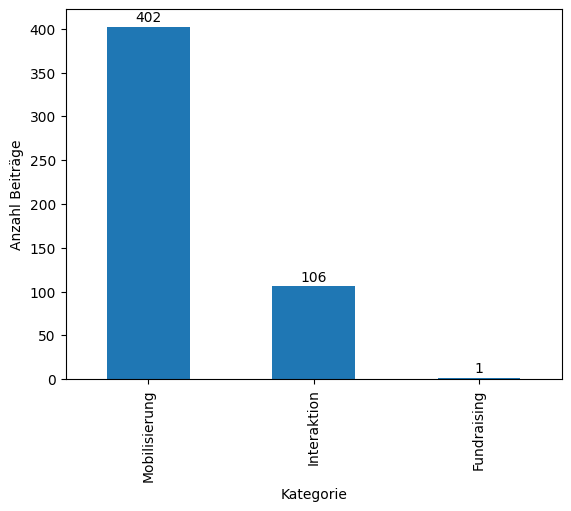

In [ ]:
import matplotlib.pyplot as plt

cat_counts = df['Kategorie'].value_counts()

ax = cat_counts.plot(kind='bar')

for i, count in enumerate(cat_counts):
    ax.text(i, count + 6, str(count), ha='center')

plt.xlabel('Kategorie')
plt.ylabel('Anzahl Beiträge')
plt.title('')

plt.show()

In [ ]:
fundraising_df = df.loc[df['Kategorie'] == 'Interaktion']
fundraising_df

,Unnamed: 0.1,Unnamed: 0,id,thread_id,parent_id,body,author,author_fullname,author_avatar_url,timestamp,...,num_likes,num_comments,num_media,location_name,location_latlong,location_city,unix_timestamp,image_file,ocr_text,Kategorie
114,114,114,CuJSyD8IEBp,CuJSyD8IEBp,CuJSyD8IEBp,+++ TV-Tipp! – Vorsitzender der #AfD-Fraktion ...,afdlandtagbayern,AfD im Landtag von Bayern,https://scontent-fra5-1.cdninstagram.com/v/t51...,01.07.2023 06:46,...,103.0,0.0,1.0,NaN,NaN,NaN,1.688194e+09,media/images/CuJSyD8IEBp.jpg,Fraktionsvorsitzender Ulrich Singer Live am So...,Interaktion
117,117,117,CuE_Aj9olOH,CuE_Aj9olOH,CuE_Aj9olOH,+++ Thüringer Verfassungsschutz-Präsident besc...,afdlandtagbayern,AfD im Landtag von Bayern,https://scontent-fra5-1.cdninstagram.com/v/t51...,29.06.2023 14:37,...,203.0,28.0,1.0,NaN,NaN,NaN,1.688049e+09,media/images/CuE_Aj9olOH.jpg,"IST DAS NOCH VERFASSUNGSKONFORM? ""VERFASSUNGSH...",Interaktion
122,122,122,Ct_D-qcIyhI,Ct_D-qcIyhI,Ct_D-qcIyhI,+++ TV-Tipp! – Innenpolitischer Sprecher der #...,afdlandtagbayern,AfD im Landtag von Bayern,https://scontent-fra5-1.cdninstagram.com/v/t51...,27.06.2023 07:25,...,96.0,0.0,1.0,NaN,NaN,NaN,1.687851e+09,media/images/Ct_D-qcIyhI.jpg,Innenpolitischer Sprecher Richard Graupner Liv...,Interaktion
199,199,199,CryXjveIBcI,CryXjveIBcI,CryXjveIBcI,+++ Wie eng ist die CSU mit türkischen Lobby-V...,afdlandtagbayern,AfD im Landtag von Bayern,https://scontent-fra5-1.cdninstagram.com/v/t51...,03.05.2023 16:03,...,75.0,14.0,1.0,NaN,NaN,NaN,1.683130e+09,media/images/CryXjveIBcI.jpg,WELCHE KONTAKTE HAT DIE SÖDER-CSU ZUM ERDOGAN-...,Interaktion
328,328,328,Cv9FM7wIxye,Cv9FM7wIxye,Cv9FM7wIxye,In vielen besonders katholisch geprägten Teile...,afd.bayern,AfD Bayern,https://scontent-fra5-1.cdninstagram.com/v/t51...,15.08.2023 06:00,...,362.0,5.0,1.0,"Bayern, Germany","48.894107570617,11.583000803261",NaN,1.692079e+09,media/images/Cv9FM7wIxye.jpg,64A4 #nnya 15 AUgUST 2023 AfD,Interaktion
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2809,2809,2809,CwAJ6ALoUFa,CwAJ6ALoUFa,CwAJ6ALoUFa,Als sogenannte Unicorn-Unternehmen werden Star...,fdpbayern,FDP Bayern,https://scontent-fra3-1.cdninstagram.com/v/t51...,16.08.2023 10:38,...,169.0,1.0,1.0,NaN,NaN,NaN,1.692182e+09,media/images/CwAJ6ALoUFa.jpg,FDP Start-ups Es gibt Einhörner. Man muss sie ...,Interaktion
2840,2840,2840,Cs8FyqJI-EA,Cs8FyqJI-EA,Cs8FyqJI-EA,Mit @muenchen.tv habe ich über notwendige Korr...,_martinhagen,Martin Hagen,https://scontent-fra5-2.cdninstagram.com/v/t51...,01.06.2023 07:15,...,136.0,5.0,1.0,NaN,NaN,NaN,1.685604e+09,media/images/Cs8FyqJI-EA.jpg,NaN,Interaktion
2932,2932,2932,CwC8FytNVNG,CwC8FytNVNG,CwC8FytNVNG,@dielinke ist eine Mitmachpartei und unsere Ka...,dielinke.bayern,DIE LINKE. Bayern,https://scontent-fra5-1.cdninstagram.com/v/t51...,17.08.2023 12:35,...,141.0,2.0,10.0,NaN,NaN,NaN,1.692276e+09,media/images/CwC8FytNVNG.jpg,Keine Unter- nehmensspenden 0 Keine Masken - d...,Interaktion
2957,2957,2957,CuKPxbmKWHx,CuKPxbmKWHx,CuKPxbmKWHx,Erst das #Asylrecht massiv einschränken und si...,dielinke.bayern,DIE LINKE. Bayern,https://scontent-fra5-1.cdninstagram.com/v/t51...,01.07.2023 15:39,...,158.0,14.0,2.0,Odeonsplatz,"48.142222222222,11.5775",NaN,1.688226e+09,media/images/CuKPxbmKWHx.jpg,Recht #stopgeas auf Asvl verteidigen JETZT ist...,Interaktion


Quellen:

Michael Achmann. (2023). michaelachmann/social-media-lab: 2023-11-27 (v0.0.12). Zenodo. https://doi.org/10.5281/zenodo.8199901